In [85]:
# Import all required libraries
# ============================================================
# BANK MARKETING - DECISION TREE CLASSIFICATION
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Visualization style
sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [86]:
# load the dataset
df = pd.read_csv("/content/Task 3 Dataset Prodigy Internship Data Science.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [87]:
# Display the first few records
print("First 10 rows of the dataset:")
display(df.head(10))

First 10 rows of the dataset:


,age,job,marital,education,balance,housing,loan,contact,campaign,pdays,previous,poutcome,purchase
0,56,admin.,married,tertiary,-79,yes,no,cellular,9,-1,0,failure,no
1,69,entrepreneur,married,secondary,9465,yes,no,unknown,3,-1,1,unknown,yes
2,46,retired,single,secondary,446,no,no,telephone,10,-1,3,success,no
3,32,retired,married,primary,8878,no,no,unknown,4,7,4,failure,no
4,60,self-employed,married,secondary,1334,no,no,cellular,10,-1,2,unknown,no
5,25,management,married,tertiary,1064,yes,no,unknown,8,-1,3,success,no
6,38,blue-collar,married,secondary,6832,no,no,cellular,6,-1,4,unknown,no
7,56,services,married,secondary,4444,no,no,cellular,7,14,1,failure,no
8,36,student,married,secondary,9639,yes,no,unknown,7,-1,5,other,no
9,40,retired,married,tertiary,808,yes,no,unknown,4,22,2,failure,no


In [88]:
# Check dataset dimensions
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 2000
Number of Columns: 13


In [89]:
# Understand all variables
print("Column Names:")
for i, column in enumerate(df.columns, 1):
    print(i, "-", column)

Column Names:
1 - age
2 - job
3 - marital
4 - education
5 - balance
6 - housing
7 - loan
8 - contact
9 - campaign
10 - pdays
11 - previous
12 - poutcome
13 - purchase


In [90]:
# Basic information about the dataset
print("DATASET INFORMATION")
print("=" * 60)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        2000 non-null   int64 
 1   job        2000 non-null   object
 2   marital    2000 non-null   object
 3   education  2000 non-null   object
 4   balance    2000 non-null   int64 
 5   housing    2000 non-null   object
 6   loan       2000 non-null   object
 7   contact    2000 non-null   object
 8   campaign   2000 non-null   int64 
 9   pdays      2000 non-null   int64 
 10  previous   2000 non-null   int64 
 11  poutcome   2000 non-null   object
 12  purchase   2000 non-null   object
dtypes: int64(5), object(8)
memory usage: 203.3+ KB


In [91]:
# Statistical summary
print("STATISTICAL SUMMARY")
display(df.describe(include='all').T)

STATISTICAL SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,2000.0,NaN,NaN,NaN,44.3765,15.226644,18.0,31.0,45.0,57.0,70.0
job,2000,11,retired,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,2000,3,married,1212,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,2000,3,secondary,1072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,2000.0,NaN,NaN,NaN,4598.868,3015.820678,-498.0,2014.5,4507.0,7189.25,9996.0
housing,2000,2,yes,1136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,2000,2,no,1702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,2000,3,cellular,1307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign,2000.0,NaN,NaN,NaN,5.5465,2.876973,1.0,3.0,6.0,8.0,10.0
pdays,2000.0,NaN,NaN,NaN,4.8655,9.466954,-1.0,-1.0,-1.0,9.0,30.0


In [92]:
# Check missing values
missing = df.isnull().sum()

missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': (missing / len(df)) * 100
})

display(missing_table)

,Missing Values,Percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
campaign,0,0.0
pdays,0,0.0


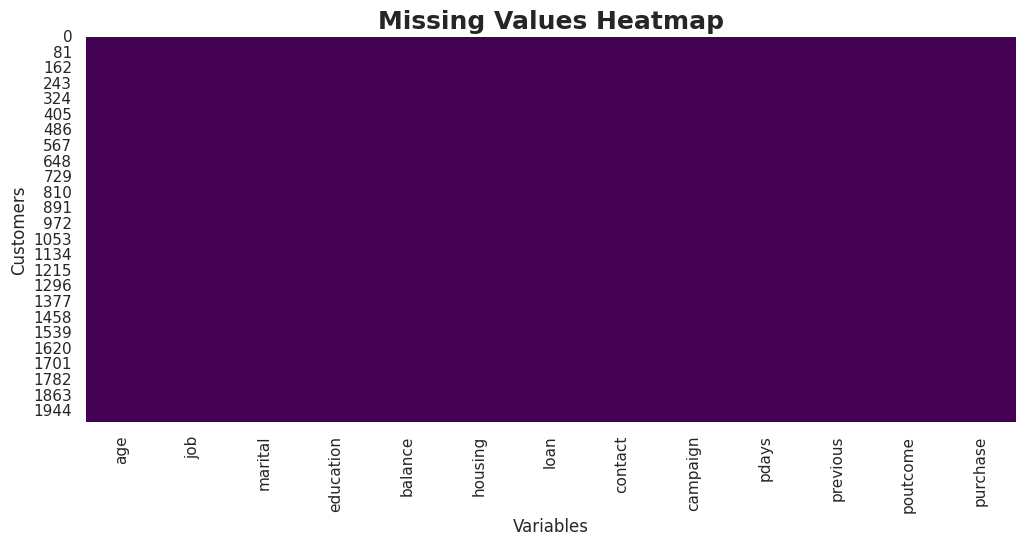

In [93]:
# missing-value visualization
plt.figure(figsize=(12, 5))
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)
plt.title(
    "Missing Values Heatmap",
    fontsize=18,
    fontweight='bold'
)
plt.xlabel("Variables")
plt.ylabel("Customers")
plt.show()

In [94]:
# Check duplicate records
duplicates = df.duplicated().sum()
print("Number of duplicate records:", duplicates)

Number of duplicate records: 0


In [95]:
# Remove duplicates if present
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (2000, 13)


In [96]:
# Check target variable
print("Purchase Distribution:")
print(df['purchase'].value_counts())

Purchase Distribution:
purchase
no     1640
yes     360
Name: count, dtype: int64


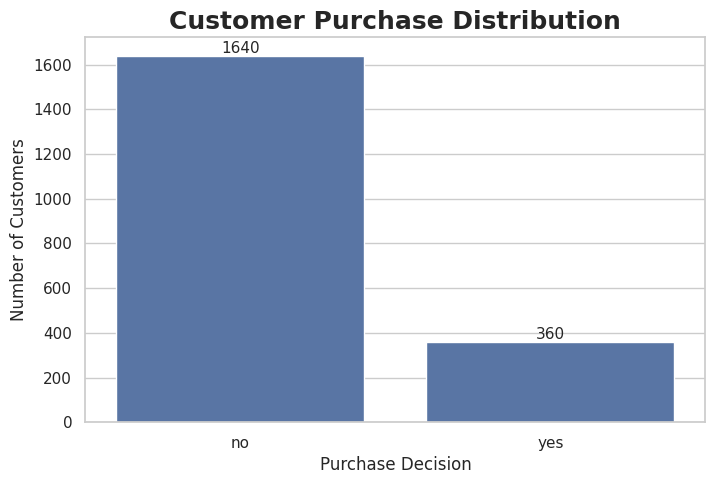

In [97]:
# purchase distribution
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='purchase'
)

plt.title(
    "Customer Purchase Distribution",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Purchase Decision")
plt.ylabel("Number of Customers")

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.show()

In [98]:
# Purchase percentage
purchase_percentage = (
    df['purchase']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Purchase Percentage:")
print(purchase_percentage)

Purchase Percentage:
purchase
no     82.0
yes    18.0
Name: proportion, dtype: float64


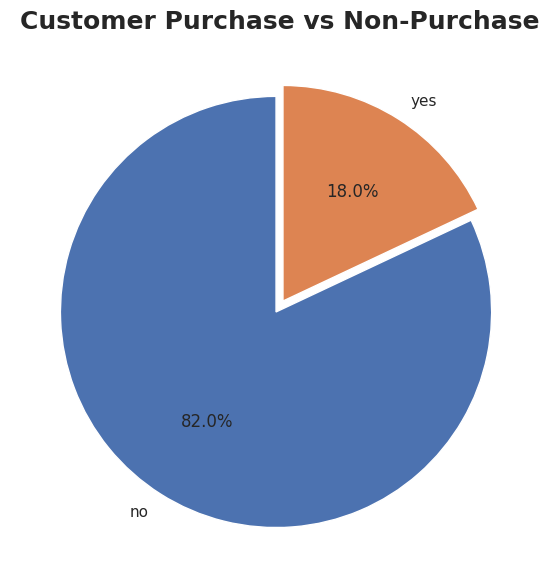

In [99]:
plt.figure(figsize=(7, 7))

df['purchase'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.03, 0.03]
)

plt.title(
    "Customer Purchase vs Non-Purchase",
    fontsize=18,
    fontweight='bold'
)

plt.ylabel("")
plt.show()

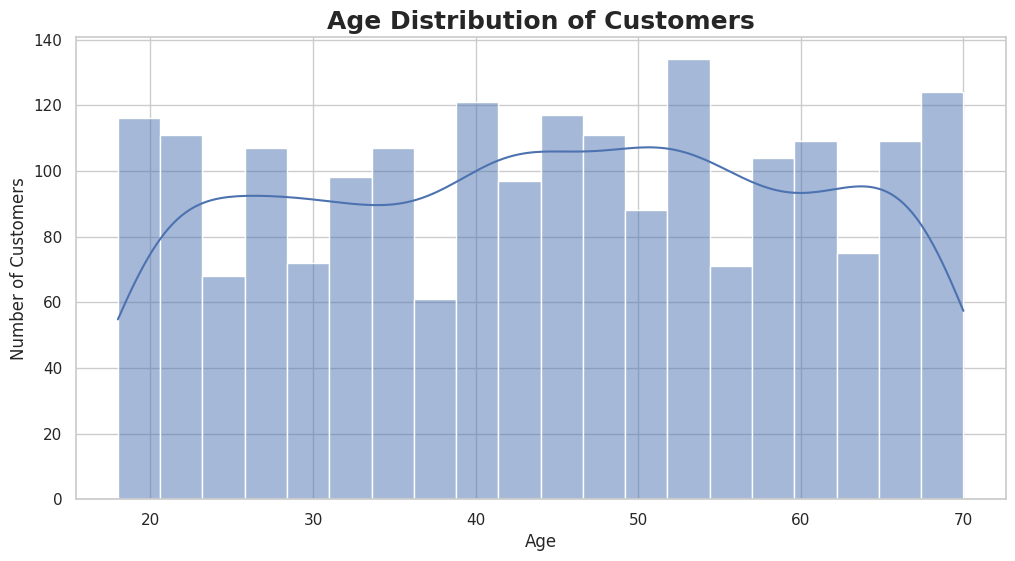

In [100]:
# Age distribution
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x='age',
    bins=20,
    kde=True
)

plt.title(
    "Age Distribution of Customers",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

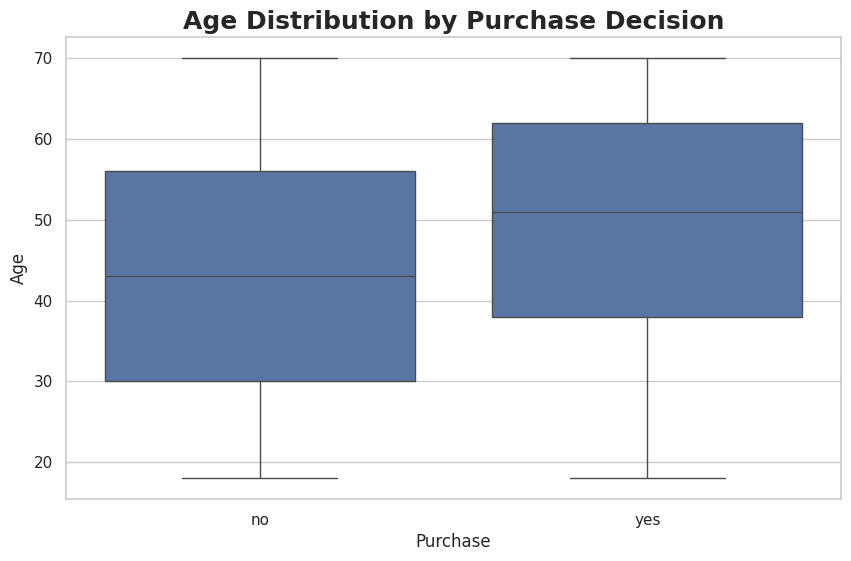

In [101]:
# Age vs purchase decision
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='purchase',
    y='age'
)

plt.title(
    "Age Distribution by Purchase Decision",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Purchase")
plt.ylabel("Age")

plt.show()

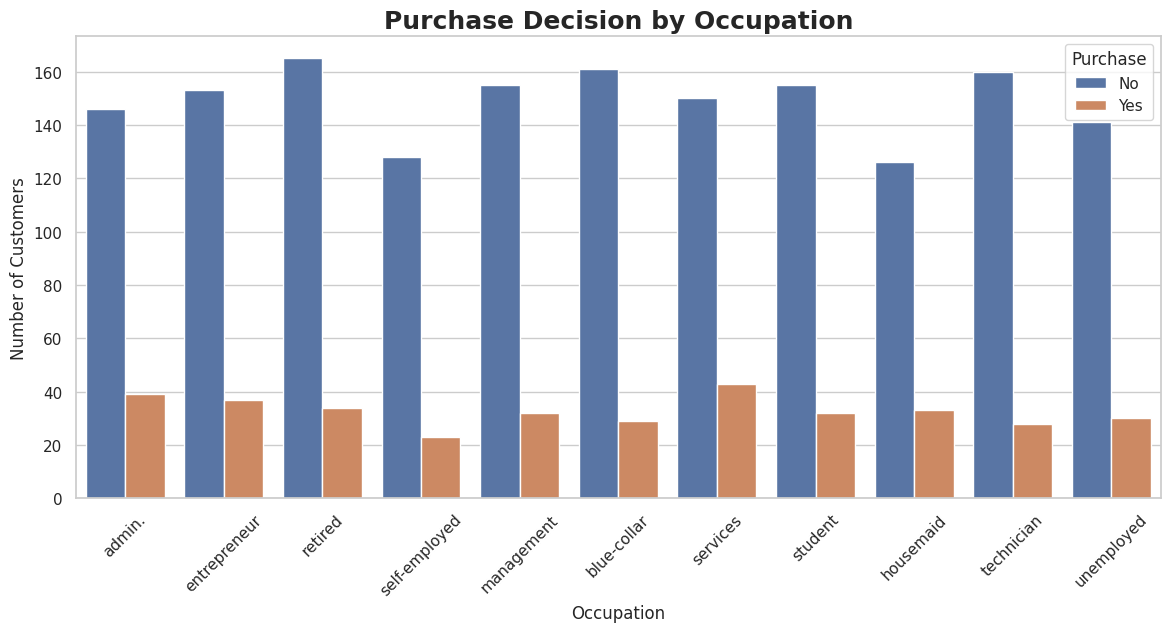

In [102]:
# Purchase by occupation
plt.figure(figsize=(14, 6))

sns.countplot(
    data=df,
    x='job',
    hue='purchase'
)

plt.title(
    "Purchase Decision by Occupation",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Occupation")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.legend(
    title="Purchase",
    labels=["No", "Yes"]
)

plt.show()

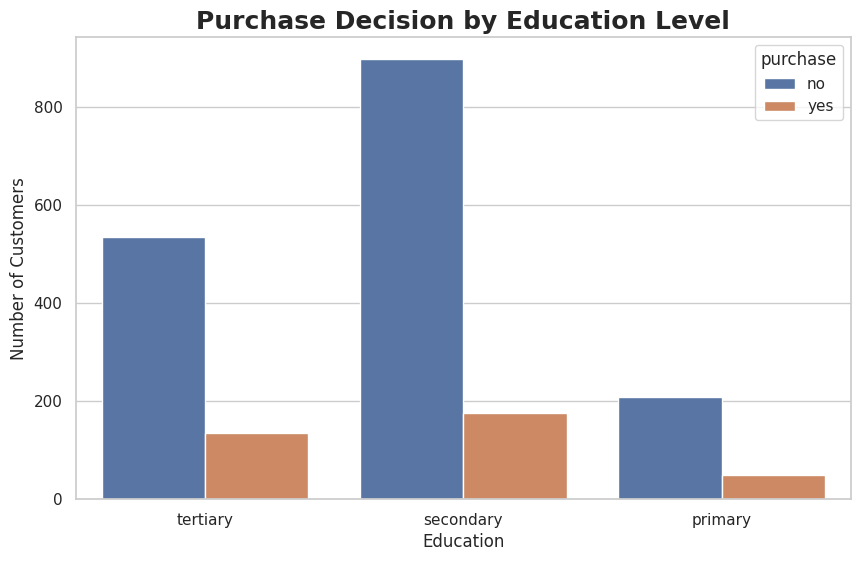

In [103]:
# Education vs purchase
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='education',
    hue='purchase'
)

plt.title(
    "Purchase Decision by Education Level",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Education")
plt.ylabel("Number of Customers")

plt.show()

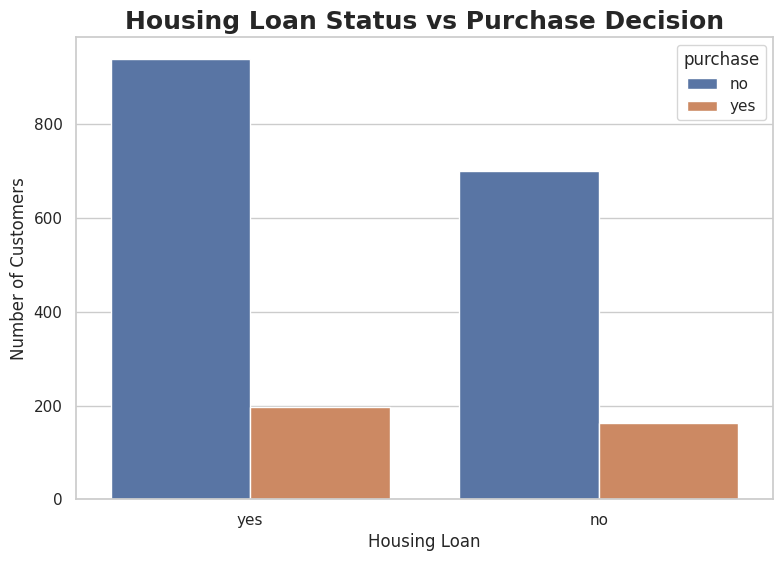

In [104]:
# Housing loan vs purchase
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x='housing',
    hue='purchase'
)

plt.title(
    "Housing Loan Status vs Purchase Decision",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Housing Loan")
plt.ylabel("Number of Customers")

plt.show()

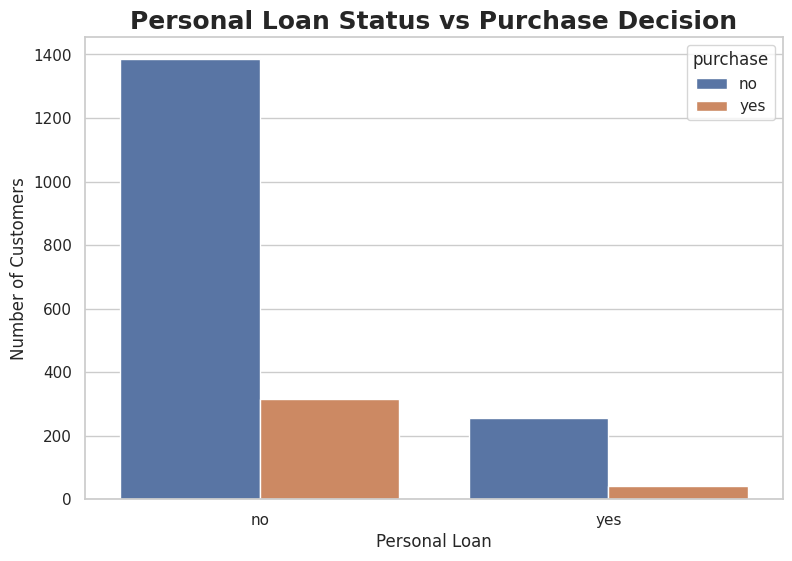

In [105]:
# Personal loan vs purchase
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x='loan',
    hue='purchase'
)

plt.title(
    "Personal Loan Status vs Purchase Decision",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Personal Loan")
plt.ylabel("Number of Customers")

plt.show()

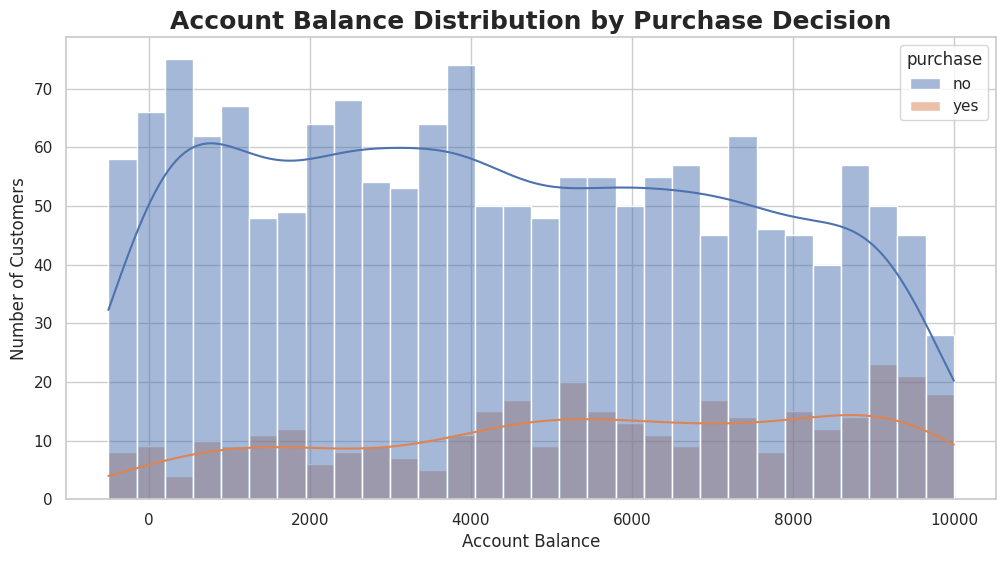

In [106]:
# Account balance distribution
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x='balance',
    hue='purchase',
    bins=30,
    kde=True
)

plt.title(
    "Account Balance Distribution by Purchase Decision",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Account Balance")
plt.ylabel("Number of Customers")

plt.show()

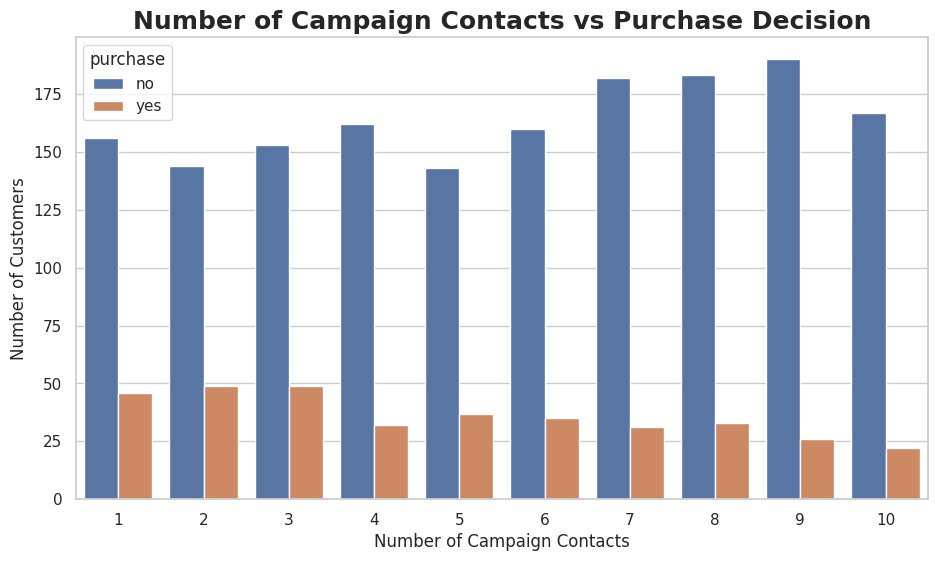

In [107]:
# Campaign contacts vs purchase
plt.figure(figsize=(11, 6))

sns.countplot(
    data=df,
    x='campaign',
    hue='purchase'
)

plt.title(
    "Number of Campaign Contacts vs Purchase Decision",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Number of Campaign Contacts")
plt.ylabel("Number of Customers")

plt.show()

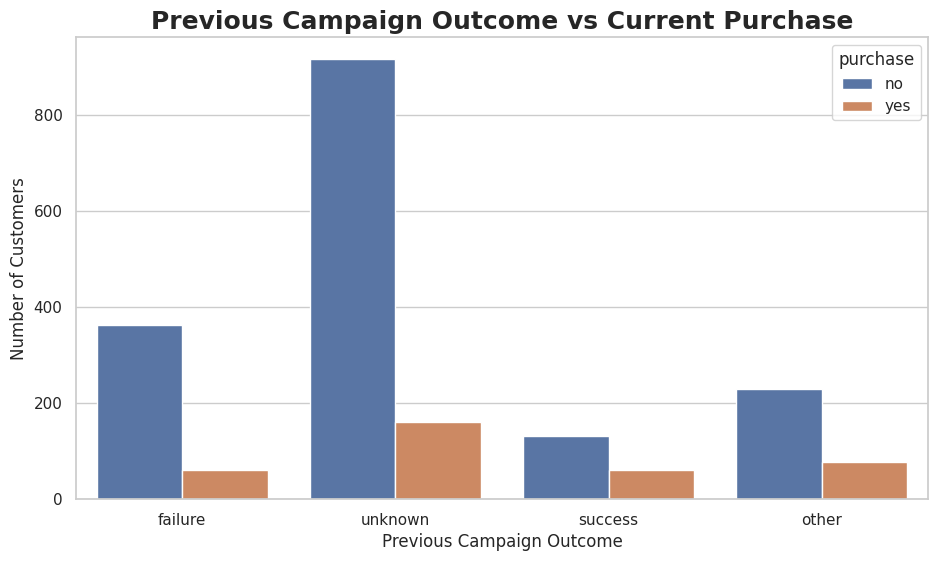

In [108]:
# Previous campaign outcome
plt.figure(figsize=(11, 6))

sns.countplot(
    data=df,
    x='poutcome',
    hue='purchase'
)

plt.title(
    "Previous Campaign Outcome vs Current Purchase",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Number of Customers")

plt.show()

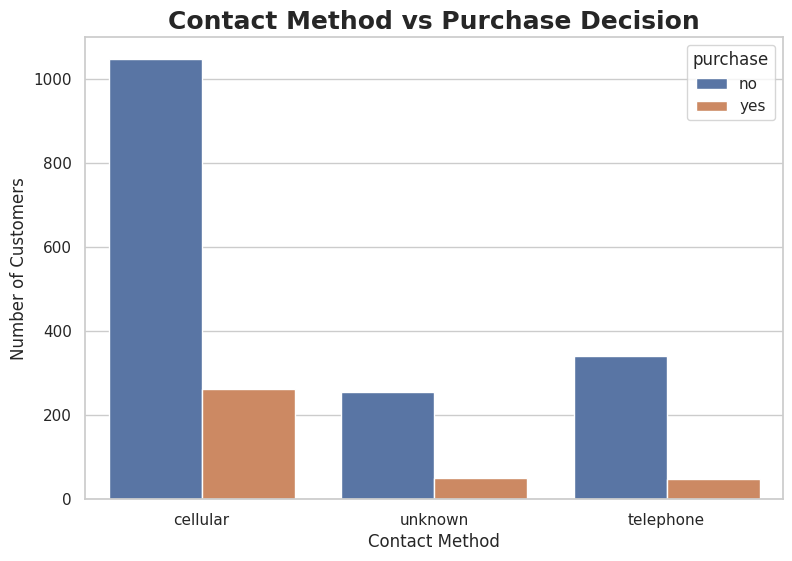

In [109]:
# Contact method vs purchase
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x='contact',
    hue='purchase'
)

plt.title(
    "Contact Method vs Purchase Decision",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Contact Method")
plt.ylabel("Number of Customers")

plt.show()

In [110]:
# Correlation analysis
df['purchase_numeric'] = df['purchase'].map({
    'no': 0,
    'yes': 1
})
numeric_columns = [
    'age',
    'balance',
    'campaign',
    'pdays',
    'previous',
    'purchase_numeric'
]

correlation = df[numeric_columns].corr()

display(correlation)

,age,balance,campaign,pdays,previous,purchase_numeric
age,1.000000,-0.016664,0.008410,0.029388,-0.007382,0.138538
balance,-0.016664,1.000000,0.009653,0.026034,-0.008915,0.144305
campaign,0.008410,0.009653,1.000000,-0.020865,0.037858,-0.112097
pdays,0.029388,0.026034,-0.020865,1.000000,-0.009259,0.004458
previous,-0.007382,-0.008915,0.037858,-0.009259,1.000000,0.002505
purchase_numeric,0.138538,0.144305,-0.112097,0.004458,0.002505,1.000000


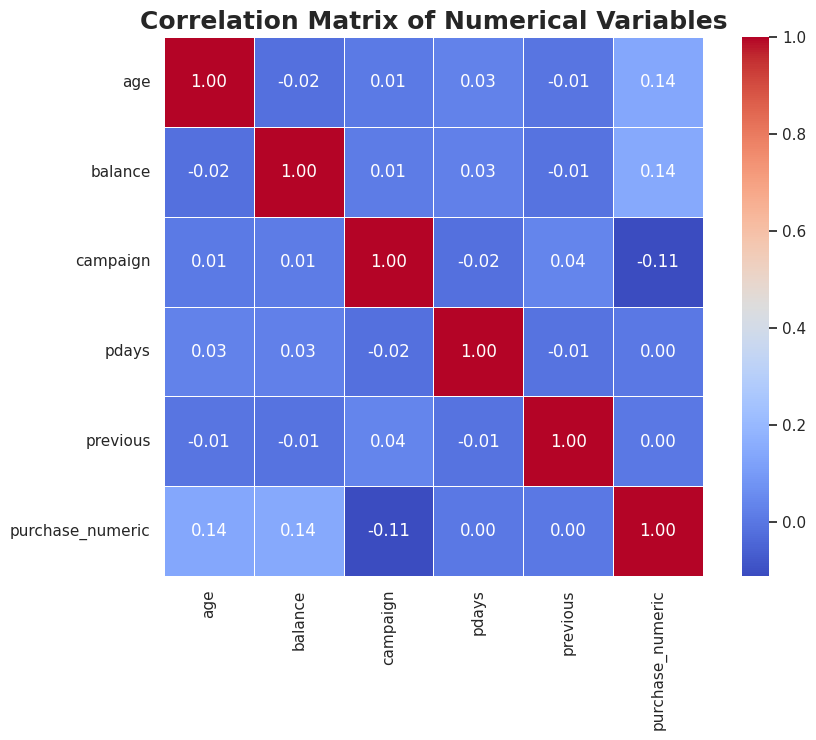

In [111]:
# correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Matrix of Numerical Variables",
    fontsize=18,
    fontweight='bold'
)

plt.show()

In [112]:
# Prepare data for Machine Learning
df_model = df.drop(columns=['purchase_numeric'])

In [113]:
# Define features
features = [
    'age',
    'job',
    'marital',
    'education',
    'balance',
    'housing',
    'loan',
    'contact',
    'campaign',
    'pdays',
    'previous',
    'poutcome'
]

X = df_model[features]
y = df_model['purchase']

In [114]:
# Convert categorical variables into numerical values
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

print("Original number of features:", X.shape[1])
print("Features after encoding:", X_encoded.shape[1])

Original number of features: 12
Features after encoding: 26


In [115]:
# Convert target variable
y = y.map({
    'no': 0,
    'yes': 1
})

print(y.value_counts())

purchase
0    1640
1     360
Name: count, dtype: int64


In [116]:
# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 1600
Testing observations: 400


In [117]:
# Build the Decision Tree
decision_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [118]:
# Make predictions
y_pred = decision_tree.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


In [119]:
# Model accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Decision Tree Accuracy:")
print(f"{accuracy * 100:.2f}%")

Decision Tree Accuracy:
80.25%


In [120]:
# Precision, Recall and F1 Score
precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.2941
Recall    : 0.0694
F1 Score  : 0.1124


In [121]:
# Complete classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'No Purchase',
            'Purchase']))

              precision    recall  f1-score   support

 No Purchase       0.83      0.96      0.89       328
    Purchase       0.29      0.07      0.11        72

    accuracy                           0.80       400
   macro avg       0.56      0.52      0.50       400
weighted avg       0.73      0.80      0.75       400



In [122]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[316  12]
 [ 67   5]]


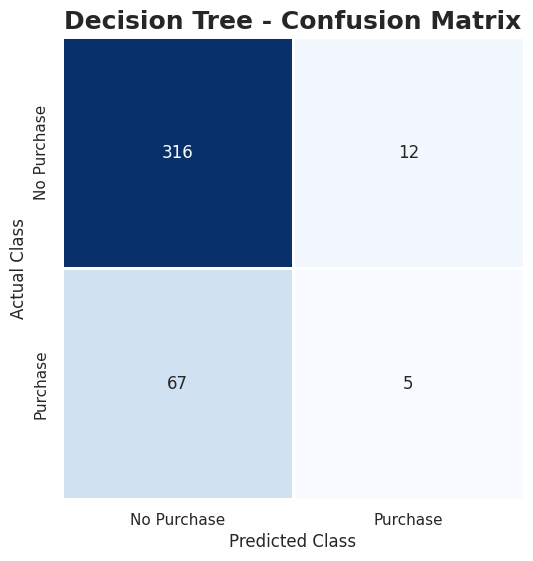

In [123]:
# Confusion Matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=2,
    square=True,
    cbar=False,
    xticklabels=['No Purchase', 'Purchase'],
    yticklabels=['No Purchase', 'Purchase']
)

plt.title(
    "Decision Tree - Confusion Matrix",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [124]:
# ROC Curve and AUC
y_probability = decision_tree.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

auc_score = roc_auc_score(
    y_test,
    y_probability
)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.6027


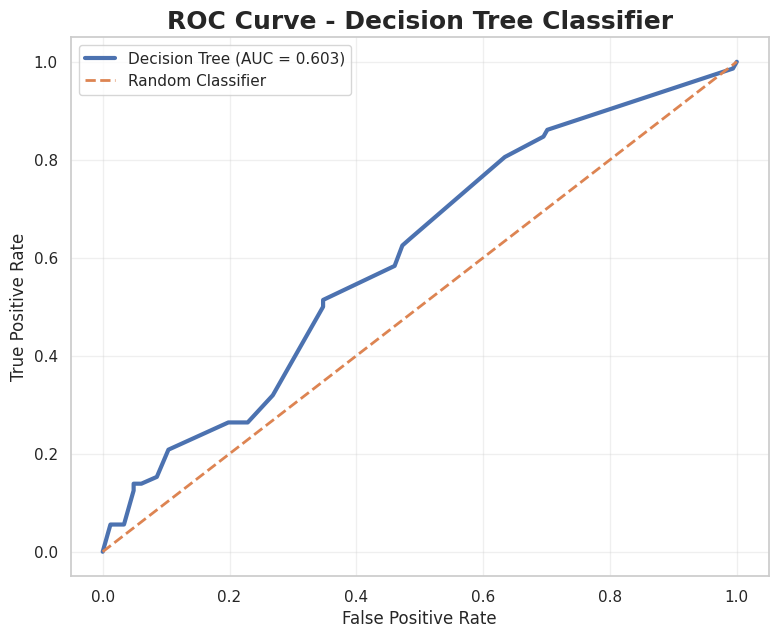

In [125]:
# Plot ROC curve
plt.figure(figsize=(9, 7))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"Decision Tree (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=2,
    label='Random Classifier'
)

plt.title(
    "ROC Curve - Decision Tree Classifier",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [126]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': decision_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(
    feature_importance.head(15)
)

,Feature,Importance
1,balance,0.268841
2,campaign,0.218994
0,age,0.157312
24,poutcome_success,0.087415
18,education_tertiary,0.044617
3,pdays,0.042208
17,education_secondary,0.041475
5,job_blue-collar,0.041121
25,poutcome_unknown,0.036071
23,poutcome_other,0.028492


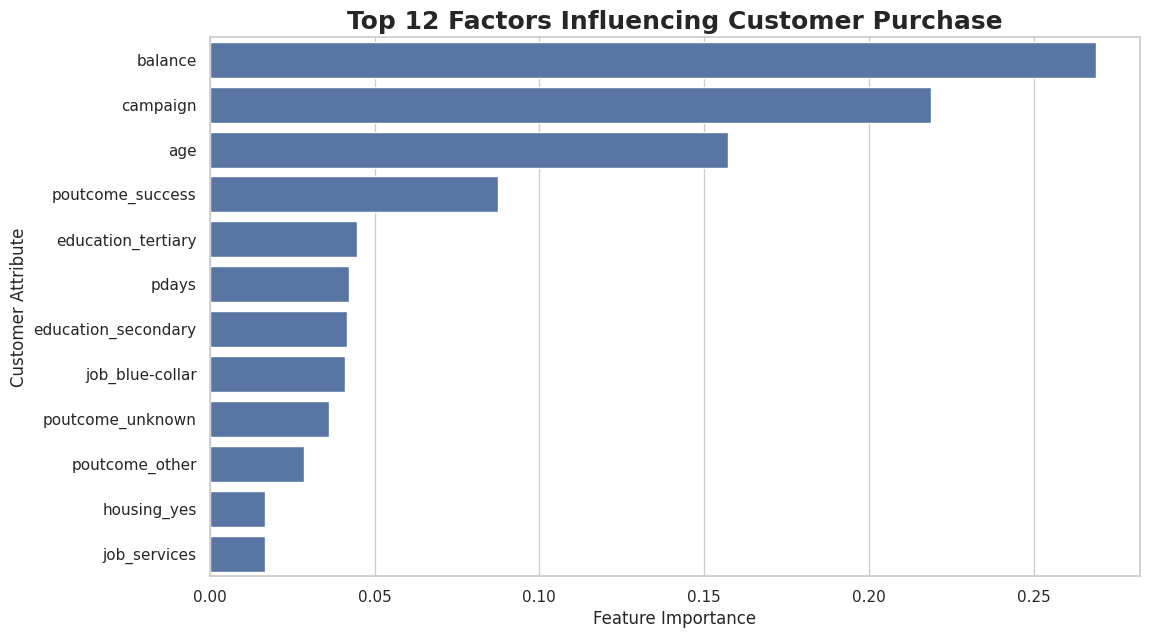

In [127]:
# Attractive Feature Importance Graph
top_features = feature_importance.head(12)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 12 Factors Influencing Customer Purchase",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Feature Importance")
plt.ylabel("Customer Attribute")

plt.show()

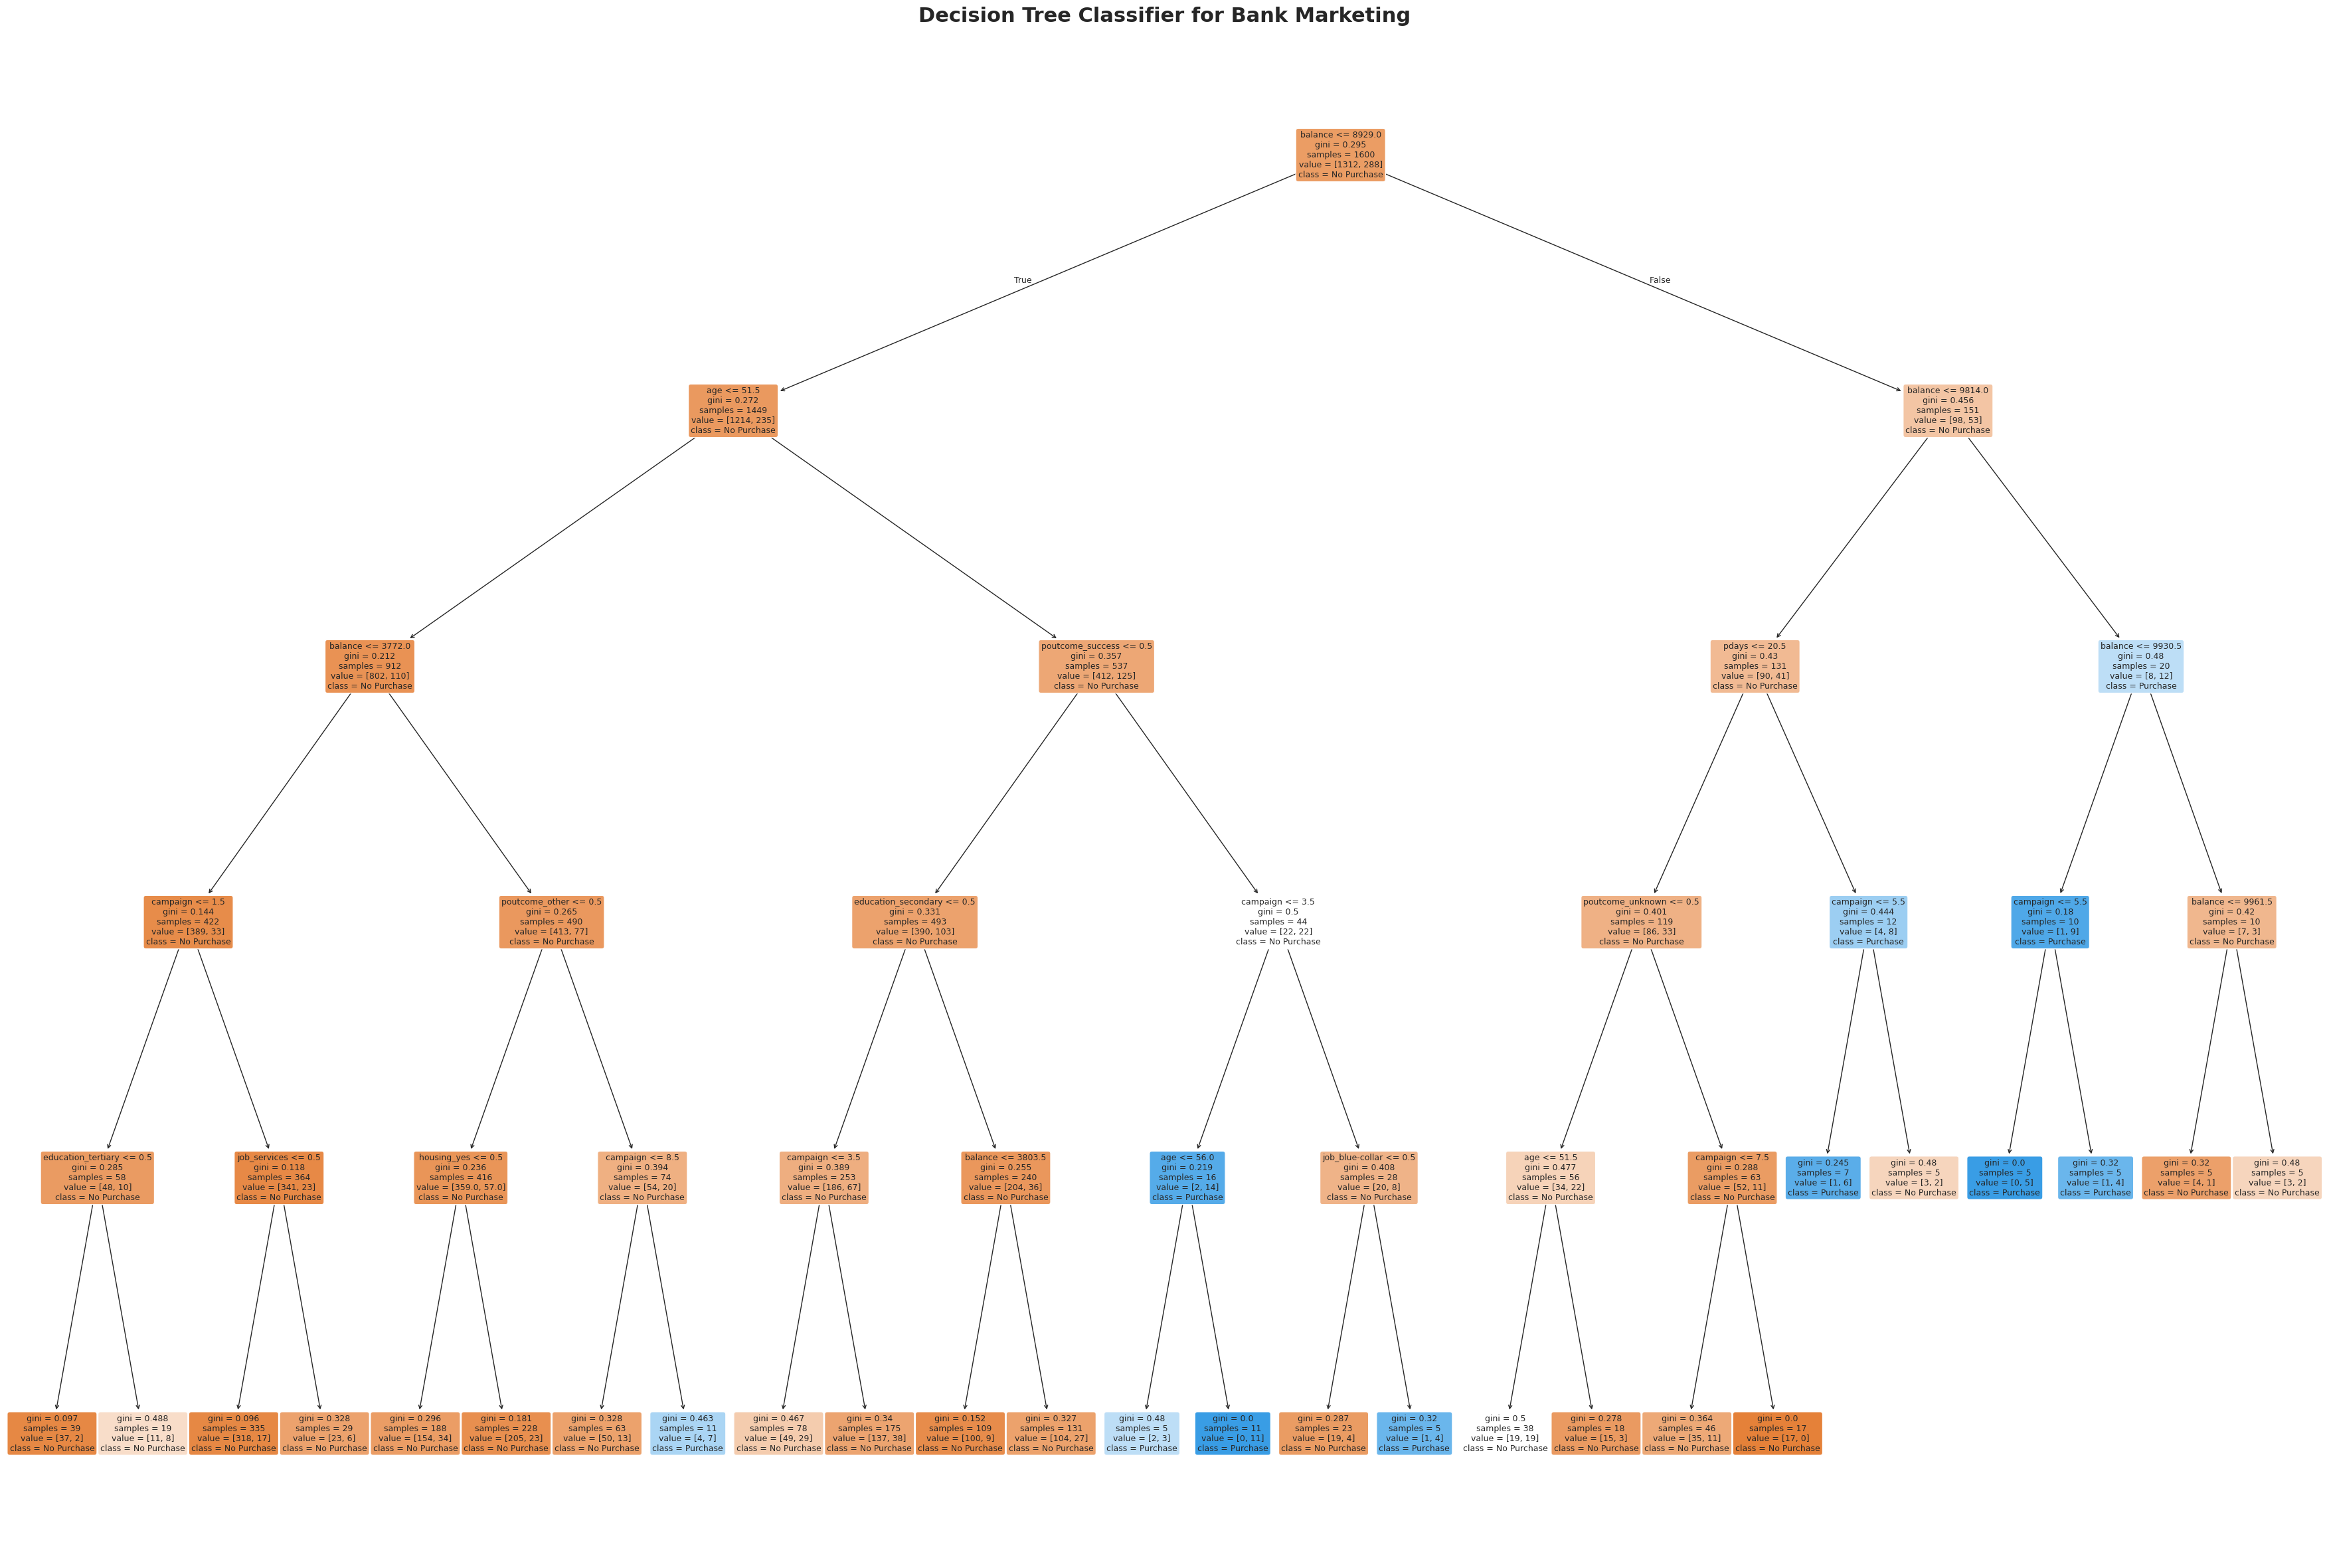

In [128]:
# Visualize the Decision Tree
plt.figure(figsize=(45,30))

plot_tree(
    decision_tree,
    feature_names=X_encoded.columns,
    class_names=[
        'No Purchase',
        'Purchase'
    ],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    "Decision Tree Classifier for Bank Marketing",
    fontsize=22,
    fontweight='bold'
)

plt.show()

In [129]:
# Analyze tree depth
depths = range(1, 16)

train_scores = []
test_scores = []

for depth in depths:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_scores.append(
        tree.score(X_train, y_train)
    )

    test_scores.append(
        tree.score(X_test, y_test)
    )

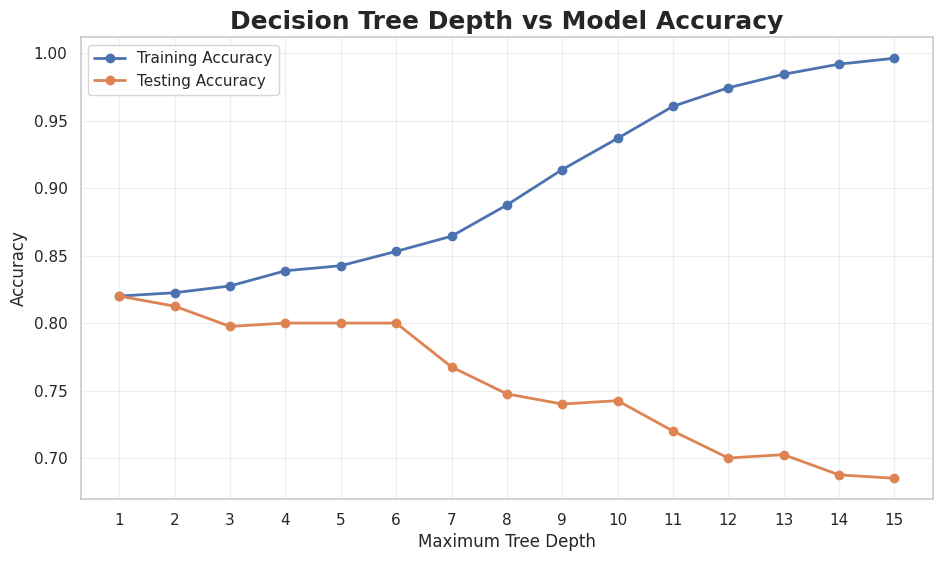

In [130]:
# Plot it
plt.figure(figsize=(11, 6))

plt.plot(
    depths,
    train_scores,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    depths,
    test_scores,
    marker='o',
    linewidth=2,
    label='Testing Accuracy'
)

plt.title(
    "Decision Tree Depth vs Model Accuracy",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")

plt.xticks(depths)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [131]:
# Compare different Decision Tree criteria
criteria = ['gini', 'entropy', 'log_loss']

criterion_results = []

for criterion in criteria:

    tree = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=5,
        random_state=42
    )

    tree.fit(X_train, y_train)

    predictions = tree.predict(X_test)

    score = accuracy_score(
        y_test,
        predictions
    )

    criterion_results.append({
        'Criterion': criterion,
        'Accuracy': score
    })

criterion_df = pd.DataFrame(
    criterion_results
)

display(criterion_df)

,Criterion,Accuracy
0,gini,0.80
1,entropy,0.78
2,log_loss,0.78


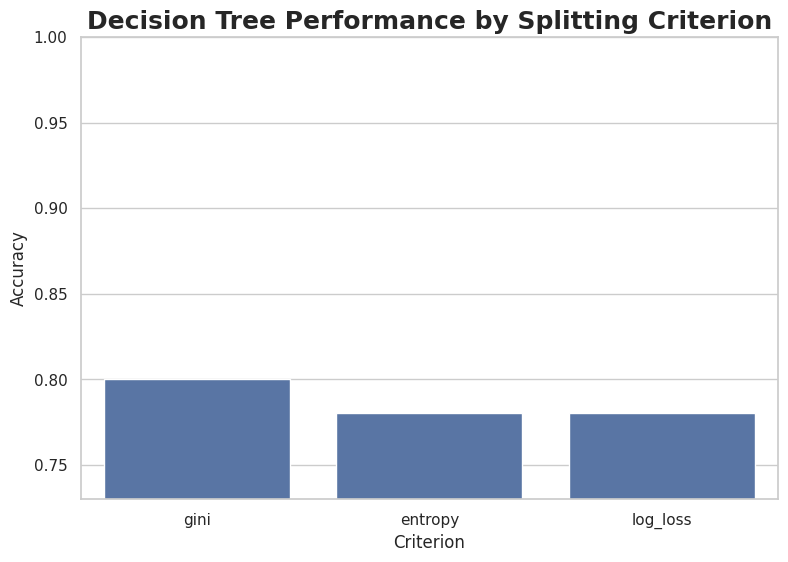

In [132]:
# Visualize
plt.figure(figsize=(9, 6))

sns.barplot(
    data=criterion_df,
    x='Criterion',
    y='Accuracy'
)

plt.title(
    "Decision Tree Performance by Splitting Criterion",
    fontsize=18,
    fontweight='bold'
)

plt.ylim(
    criterion_df['Accuracy'].min() - 0.05,
    1
)

plt.show()

In [133]:
# Predict a new customer
new_customer = pd.DataFrame({
    'age': [35],
    'job': ['management'],
    'marital': ['single'],
    'education': ['tertiary'],
    'balance': [5000],
    'housing': ['no'],
    'loan': ['no'],
    'contact': ['cellular'],
    'campaign': [2],
    'pdays': [10],
    'previous': [2],
    'poutcome': ['success']
})

display(new_customer)

,age,job,marital,education,balance,housing,loan,contact,campaign,pdays,previous,poutcome
0,35,management,single,tertiary,5000,no,no,cellular,2,10,2,success


In [134]:
# Encode the new customer
new_customer_encoded = pd.get_dummies(
    new_customer
)

new_customer_encoded = new_customer_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

In [135]:
# Predict whether the customer purchases
prediction = decision_tree.predict(
    new_customer_encoded
)

probability = decision_tree.predict_proba(
    new_customer_encoded
)

if prediction[0] == 1:
    result = "LIKELY TO PURCHASE"
else:
    result = "UNLIKELY TO PURCHASE"

print("====================================")
print(" CUSTOMER PURCHASE PREDICTION")
print("====================================")
print("Prediction:", result)
print(f"Probability of No Purchase: {probability[0][0]*100:.2f}%")
print(f"Probability of Purchase: {probability[0][1]*100:.2f}%")
print("====================================")

 CUSTOMER PURCHASE PREDICTION
Prediction: UNLIKELY TO PURCHASE
Probability of No Purchase: 81.91%
Probability of Purchase: 18.09%


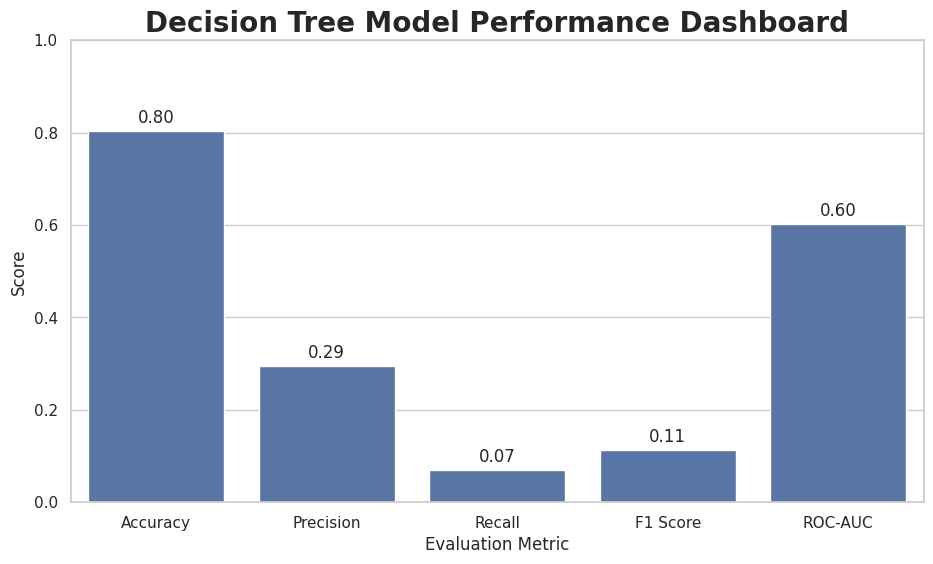

In [136]:
# Create a professional model performance dashboard
metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'ROC-AUC': auc_score
}

metrics_df = pd.DataFrame(
    list(metrics.items()),
    columns=['Metric', 'Score']
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=metrics_df,
    x='Metric',
    y='Score'
)

plt.title(
    "Decision Tree Model Performance Dashboard",
    fontsize=20,
    fontweight='bold'
)

plt.ylabel("Score")
plt.xlabel("Evaluation Metric")

plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.show()

In [137]:
# Automatically generate a summary
print("=" * 70)
print("          BANK MARKETING DECISION TREE PROJECT")
print("=" * 70)

print(f"\nTotal Customers       : {len(df):,}")
print(f"Training Customers    : {len(X_train):,}")
print(f"Testing Customers     : {len(X_test):,}")

print("\nMODEL PERFORMANCE")
print("-" * 40)

print(f"Accuracy              : {accuracy:.2%}")
print(f"Precision             : {precision:.2%}")
print(f"Recall                : {recall:.2%}")
print(f"F1 Score              : {f1:.2%}")
print(f"ROC-AUC               : {auc_score:.2%}")

print("\nTOP 5 IMPORTANT FEATURES")
print("-" * 40)

for i, row in feature_importance.head(5).iterrows():
    print(
        f"{row['Feature']:<30} "
        f"{row['Importance']:.4f}"
    )

print("\n" + "=" * 70)
print("                 ANALYSIS COMPLETED")
print("=" * 70)

          BANK MARKETING DECISION TREE PROJECT

Total Customers       : 2,000
Training Customers    : 1,600
Testing Customers     : 400

MODEL PERFORMANCE
----------------------------------------
Accuracy              : 80.25%
Precision             : 29.41%
Recall                : 6.94%
F1 Score              : 11.24%
ROC-AUC               : 60.27%

TOP 5 IMPORTANT FEATURES
----------------------------------------
balance                        0.2688
campaign                       0.2190
age                            0.1573
poutcome_success               0.0874
education_tertiary             0.0446

                 ANALYSIS COMPLETED
